# L3a Advanced: Limit-Order-Book Mechanics
A quoted market is not a single price. At any instant, it is a collection of standing instructions to buy and sell at specified prices. This notebook develops a __central limit-order book__ as a state that changes when traders submit, cancel, or execute orders. The organizing question is:

> If an order arrives now, what changes in the book, which orders trade, and which prices are paid?

We use a deterministic price-time-priority engine from `VLQuantitativeFinancePackage`. Prices are stored as integer ticks and quantities as whole shares, so the matching rules are exact and reproducible.

> __Learning Objectives:__
>
> By the end of this notebook, we will be able to:
>
> * __Book state:__ Define the bid and ask books, the best quotes, the spread, the midpoint, and the depth resting at each price level. Explain how price-time priority ranks the resting orders at a level so each one has a queue position fixed by its price and its arrival time.
> * __Order events:__ Distinguish passive limit orders, quote-improving limit orders, cancellations, and aggressive orders by the change each one makes to the book. Identify which of these events move displayed liquidity without producing a trade.
> * __Execution cost:__ Trace an aggressive order through successive price levels and construct the fill report and volume-weighted average price it produces. Explain why depth beyond the best quote, rather than the quoted spread alone, sets the mechanical cost of a large order.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course environment and loads the `VLQuantitativeFinancePackage` matching engine, along with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), which we use to display book snapshots and fill reports. 

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Implementation
Next, we define helper functions that we use throughout the notebook. 
* The `seed_order_book(...)` function builds a small synthetic book of resting limit orders, the `book_table(...)` and `fill_table(...)` functions convert book snapshots and fill reports into [`DataFrame` instances](https://dataframes.juliadata.org/stable/), and the `plot_order_book(...)` function draws the displayed depth profile. We also set shared plot styling defaults.

Let's define these helper functions:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    fg_legend = :transparent,
    linewidth = 2,
);

function seed_order_book(; depth_scale::Int = 1)
    book = MyOrderBook(tick_size = 0.01)
    orders = [
        MyLimitOrder(1, Buy,  9_999,  60 * depth_scale; account = 101),
        MyLimitOrder(2, Buy,  9_999,  40 * depth_scale; account = 102),
        MyLimitOrder(3, Buy,  9_998, 150 * depth_scale; account = 103),
        MyLimitOrder(4, Buy,  9_997, 250 * depth_scale; account = 104),
        MyLimitOrder(5, Sell, 10_001,  80 * depth_scale; account = 201),
        MyLimitOrder(6, Sell, 10_002, 120 * depth_scale; account = 202),
        MyLimitOrder(7, Sell, 10_003, 200 * depth_scale; account = 203),
    ]
    foreach(order -> submit_order!(book, order), orders)
    return book
end

function book_table(book; levels::Int = 5)
    view = order_book_snapshot(book; levels = levels)
    bids = DataFrame(
        side = fill("BID", length(view.bids)),
        price = getfield.(view.bids, :price),
        displayed_quantity = getfield.(view.bids, :quantity),
        resting_orders = getfield.(view.bids, :order_count),
    )
    asks = DataFrame(
        side = fill("ASK", length(view.asks)),
        price = getfield.(view.asks, :price),
        displayed_quantity = getfield.(view.asks, :quantity),
        resting_orders = getfield.(view.asks, :order_count),
    )
    result = vcat(bids, asks)
    sort!(result, :price; rev = true)
    return result
end

function fill_table(book, report)
    return DataFrame(
        resting_order_id = getfield.(report.fills, :resting_order_id),
        execution_price = [ticks_to_price(book, fill.price_ticks) for fill in report.fills],
        executed_quantity = getfield.(report.fills, :quantity),
        resting_account = getfield.(report.fills, :resting_account),
    )
end

function plot_order_book(book; levels::Int = 5, title::String = "Displayed depth")
    view = order_book_snapshot(book; levels = levels)
    p = plot(; xlabel = "Displayed quantity  (bid ← 0 → ask)", ylabel = "Price (USD/share)",
        title = title, legend = :bottomright, size = (780, 410), left_margin = 4Plots.mm,
        bottom_margin = 4Plots.mm)
    for (index, level) in enumerate(view.bids)
        plot!(p, [-level.quantity, 0], [level.price, level.price];
            color = :steelblue4, linewidth = 8, label = index == 1 ? "Bid depth" : "")
    end
    for (index, level) in enumerate(view.asks)
        plot!(p, [0, level.quantity], [level.price, level.price];
            color = :darkorange2, linewidth = 8, label = index == 1 ? "Ask depth" : "")
    end
    vline!(p, [0.0]; color = :gray50, linewidth = 1, linestyle = :dash, label = "")
    return p
end

plot_order_book (generic function with 1 method)

___

## Task 1: Read the state of the book

In this task, we'll build a small synthetic order book and read off its best bid, best ask, spread, and midpoint. Those four numbers describe the market at one instant, before any trade takes place, which is the first thing to understand about a book: it is a standing state, not a record of transactions.

At event time $t$, write the displayed bid and ask books as:

$$
\mathcal{B}_t=\{(p^b_i,q^b_i)\}_{i=1}^{N_b},
\qquad
\mathcal{A}_t=\{(p^a_i,q^a_i)\}_{i=1}^{N_a},
$$

where $p$ is a price and $q$ is the displayed quantity at that price. Bid prices run from highest to lowest and ask prices from lowest to highest, so the top of the book is given by:

$$
b_t=\max_i p^b_i,
\qquad
a_t=\min_i p^a_i.
$$

Those two quotes give the __bid-ask spread__ and the __midpoint__:

$$
s_t=a_t-b_t,
\qquad
m_t=\frac{a_t+b_t}{2}.
$$

A single price level may hold several separate orders, and the engine ranks them by __price-time priority__: better prices execute first, and among orders at the same price the earlier arrival executes first. Until an aggressive order crosses the spread and matches it, a displayed order stays an instruction rather than a trade.

Let's seed a small synthetic book and compute these quantities:

In [3]:
book = seed_order_book();
@assert validate_order_book(book);

quote_summary = DataFrame(
    best_bid = best_quotes(book).bid,
    best_ask = best_quotes(book).ask,
    spread = bid_ask_spread(book),
    midpoint = midprice(book),
    bid_quantity = displayed_volume(book, Buy),
    ask_quantity = displayed_volume(book, Sell),
)

pretty_table(quote_summary; table_format = TextTableFormat(borders = text_table_borders__simple))
book_table(book)

=========== ========== ========= ========== ============== ===============
  best_bid   best_ask    spread   midpoint   bid_quantity   ask_quantity 
   Float64    Float64   Float64    Float64          Int64          Int64 
=========== ========== ========= ========== ============== ===============
     99.99     100.01      0.02      100.0            500            400
=========== ========== ========= ========== ============== ===============


Row,side,price,displayed_quantity,resting_orders
,String,Float64,Int64,Int64
1,ASK,100.03,200,1
2,ASK,100.02,120,1
3,ASK,100.01,80,1
4,BID,99.99,100,2
5,BID,99.98,150,1
6,BID,99.97,250,1


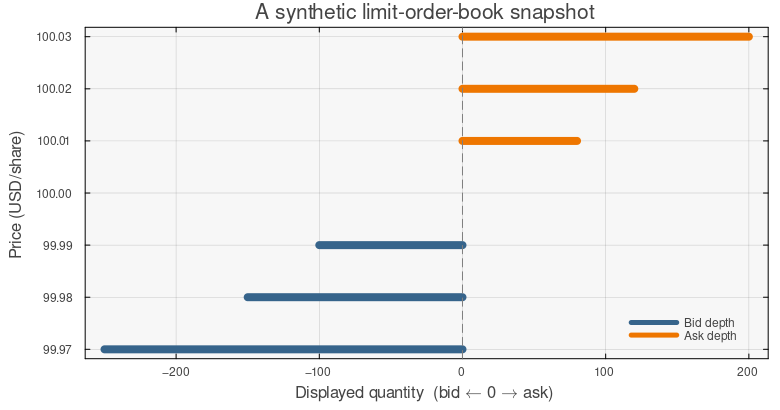

In [4]:
plot_order_book(book; title = "A synthetic limit-order-book snapshot")

The figure is a depth profile, not a transaction diagram. Bid quantity extends left from zero, and ask quantity extends right. The closest two levels are the best bid and best ask. The gap between them is the spread.

The first bid level contains two separate orders (60 shares followed by 40 shares) even though the table aggregates them into 100 displayed shares. That hidden queue structure determines which resting order fills first whenever an aggressive order reaches this price. Task 3 demonstrates the allocation rule.

___

## Task 2: Change the book with passive orders

In this task, we'll add resting limit orders to the book and then cancel one, watching what each event does to the quotes. Neither event is a trade, because both only change the standing instructions that a later trade will meet.

A buy limit order priced below the best ask does not execute on arrival. It is __passive__, so it joins the bid book, and where it lands decides whether the quote moves at all. Placed at the current best bid, it adds depth behind the orders already queued there and leaves the quote alone. Placed between the current quotes, it improves the best bid and narrows the spread. Either way the order is a willingness to trade subject to a price constraint, and submitting it is not itself a purchase.

Let's add both kinds of passive order and compare the resulting quotes:

In [5]:
passive_book = seed_order_book()
stages = NamedTuple[]

push!(stages, (stage = "Initial book", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

same_price_report = submit_order!(passive_book, MyLimitOrder(8, Buy, 9_999, 70; account = 105))
push!(stages, (stage = "Add 70 at best bid", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

improving_report = submit_order!(passive_book, MyLimitOrder(9, Buy, 10_000, 50; account = 106))
push!(stages, (stage = "Add 50 inside spread", best_bid = best_quotes(passive_book).bid,
    best_ask = best_quotes(passive_book).ask, spread = bid_ask_spread(passive_book)))

@assert same_price_report.status == :resting
@assert improving_report.status == :resting

# Display the quotes after each passive order.
pretty_table(DataFrame(stages);
    column_labels = ["Stage", "Best bid (USD)", "Best ask (USD)", "Spread (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.2f", [2, 3, 4])])

======================= ================ ================ ===============
                 Stage   Best bid (USD)   Best ask (USD)   Spread (USD) 
======================= ================ ================ ===============
          Initial book            99.99           100.01           0.02
    Add 70 at best bid            99.99           100.01           0.02
  Add 50 inside spread           100.00           100.01           0.01
======================= ================ ================ ===============


In [6]:
book_table(passive_book)

Row,side,price,displayed_quantity,resting_orders
,String,Float64,Int64,Int64
1,ASK,100.03,200,1
2,ASK,100.02,120,1
3,ASK,100.01,80,1
4,BID,100.0,50,1
5,BID,99.99,170,3
6,BID,99.98,150,1
7,BID,99.97,250,1


The 70-share order increased quantity at $99.99$ but did not change the quote. The 50-share order at $100.00$ became the new best bid, reducing the spread from two cents to one cent. No execution occurred in either case.

___

### A cancellation removes an instruction

A cancellation withdraws an unexecuted resting order, and whether the quote moves depends on where that order sat. Removing depth from a level away from the best price changes the liquidity available without touching the quoted price. Removing the only order at the best price exposes the next level and moves the quote.

Let's cancel the quote-improving order and compare the quotes before and after:

In [7]:
before_cancel = best_quotes(passive_book)
cancelled = cancel_order!(passive_book, 9)
after_cancel = best_quotes(passive_book)

cancel_summary = DataFrame(
    quantity_cancelled = cancelled.quantity,
    bid_before = before_cancel.bid,
    bid_after = after_cancel.bid,
    ask_before = before_cancel.ask,
    ask_after = after_cancel.ask,
)

@assert validate_order_book(passive_book)

# Display the quotes on either side of the cancellation.
pretty_table(cancel_summary;
    column_labels = ["Quantity cancelled (shares)", "Bid before (USD)", "Bid after (USD)",
        "Ask before (USD)", "Ask after (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.2f", [2, 3, 4, 5])])

============================== ================== ================= ================== ==================
  Quantity cancelled (shares)   Bid before (USD)   Bid after (USD)   Ask before (USD)   Ask after (USD) 
============================== ================== ================= ================== ==================
                           50             100.00             99.99             100.01            100.01
============================== ================== ================= ================== ==================


The best bid reverted to $99.99$ because the quote-improving order was the only order at $100.00$. A cancellation can therefore change the publicly quoted market even though it creates no trade.

___

## Task 3: Consume the book with aggressive orders

In this task, we'll send orders that cross the spread and trade against the resting book. We follow the price a large order pays as it walks through several levels, then watch how the engine chooses between two orders sitting at the same price.

A buy market order carries no limit price. It trades first with the oldest order at the best ask, and if its quantity exceeds that queue it continues into the next ask level, a process called __walking the book__. For fills $(p_j,f_j)$, the volume-weighted average execution price is given by:

$$
\operatorname{VWAP}(Q)=\frac{1}{Q_{\mathrm{exec}}}\sum_j p_j f_j,
\qquad
Q_{\mathrm{exec}}=\sum_j f_j.
$$

VWAP is an execution statistic. For a buy order that walks the book, it comes out above the best ask quoted before the order arrived, and that gap is what consuming depth costs.

Let's send a market order large enough to clear more than one price level:

In [8]:
book_before_walk = seed_order_book()
book_after_walk = seed_order_book()
midpoint_before = midprice(book_after_walk)
market_report = submit_order!(book_after_walk, MyMarketOrder(Buy, 150))

execution_summary = DataFrame(
    requested_quantity = market_report.requested_quantity,
    executed_quantity = market_report.executed_quantity,
    unfilled_quantity = market_report.remaining_quantity,
    vwap = execution_vwap(market_report),
    initial_best_ask = best_quotes(book_before_walk).ask,
    midpoint_before = midpoint_before,
    midpoint_after = midprice(book_after_walk),
    implementation_shortfall = implementation_shortfall(market_report, midpoint_before),
)

@assert market_report.status == :filled
@assert validate_order_book(book_after_walk)
fill_table(book_after_walk, market_report)

Row,resting_order_id,execution_price,executed_quantity,resting_account
,Int64,Float64,Int64,Int64
1,5,100.01,80,201
2,6,100.02,70,202


In [9]:
# Display every execution measurement for the market order.
pretty_table(execution_summary;
    column_labels = ["Requested (shares)", "Executed (shares)", "Unfilled (shares)",
        "VWAP (USD)", "Initial best ask (USD)", "Midpoint before (USD)",
        "Midpoint after (USD)", "Implementation shortfall (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [4, 5, 6, 7, 8])])

===================== =================== =================== ============ ======================== ======================= ====================== =================================
  Requested (shares)   Executed (shares)   Unfilled (shares)   VWAP (USD)   Initial best ask (USD)   Midpoint before (USD)   Midpoint after (USD)   Implementation shortfall (USD) 
===================== =================== =================== ============ ======================== ======================= ====================== =================================
                 150                 150                   0     100.0147                 100.0100                100.0000               100.0050                           2.2000
===================== =================== =================== ============ ======================== ======================= ====================== =================================


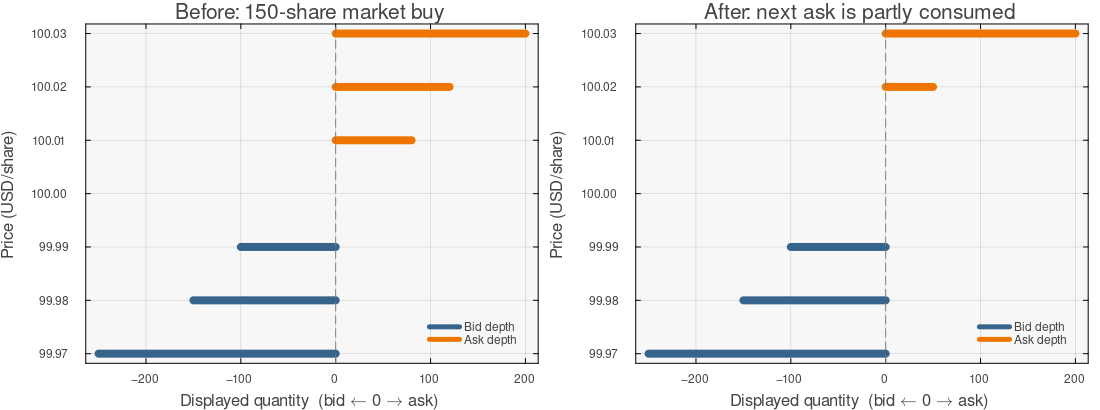

In [10]:
plot(
    plot_order_book(book_before_walk; title = "Before: 150-share market buy"),
    plot_order_book(book_after_walk; title = "After: next ask is partly consumed");
    layout = (1, 2), size = (1100, 410),
)

The order received 80 shares at $100.01$ and the remaining 70 shares at $100.02$. It exhausted the first ask level and partially consumed the second. Consequently, the best ask moved from $100.01$ to $100.02$, and the midpoint moved by half a cent because the bid did not change.

This is __mechanical impact conditional on the displayed snapshot__. It does not yet tell us whether the price change persists, whether hidden liquidity appears, or how other traders respond.

___

### Time priority operates within a price level

Two orders resting at the same price are equivalent in price but not in queue position, and the earlier one executes first. To watch that rule decide an allocation, we rest two sell orders at one price and send a buy order large enough to clear the first and part of the second.

In [11]:
fifo_book = MyOrderBook(tick_size = 0.01)
submit_order!(fifo_book, MyLimitOrder(101, Sell, 10_001, 50; account = 1))
submit_order!(fifo_book, MyLimitOrder(102, Sell, 10_001, 70; account = 2))
fifo_report = submit_order!(fifo_book, MyMarketOrder(Buy, 80))

@assert getfield.(fifo_report.fills, :resting_order_id) == [101, 102]
@assert only(account_orders(fifo_book, 2)).quantity == 40
@assert validate_order_book(fifo_book)
fill_table(fifo_book, fifo_report)

Row,resting_order_id,execution_price,executed_quantity,resting_account
,Int64,Float64,Int64,Int64
1,101,100.01,50,1
2,102,100.01,30,2


Order 101 arrived first and was completely filled. Order 102 supplied the remaining 30 shares and retained a 40-share resting remainder. The price-level aggregate alone cannot reveal this allocation, but the queue does.

___

## Summary

A limit-order book is a price-indexed collection of queued trading instructions, and every order event changes either displayed state, executed quantity, or both.

> __Key Takeaways:__
>
> * __Passive orders and cancellations reshape liquidity:__ Submitting or cancelling a resting limit order changes displayed depth, and can change the quoted prices themselves. Neither event requires a trade, so the visible market can move with no transaction printed.
> * __Aggressive orders consume price-time-priority queues:__ An order larger than the depth at the top level walks into deeper levels and fills at successively worse prices. The average price paid therefore depends on the shape of the whole book, not on the best quote alone.
> * __Impact begins with state dependence:__ Spread and depth set the immediate mechanical cost of an aggressive order, and queue position sets which resting orders fill first at a given price. How the book recovers afterward is a separate question that requires a dynamic model.

The next notebook uses these mechanics to separate book-walking cost from linear, order-flow-imbalance, and transient market-impact models.

___